# ProteomeLM vs ESM-C: Supervised MLP Benchmark
Comparison of ProteomeLM and ESM-C embeddings for PPI prediction using a simple MLP, across species (E. coli, S. cerevisiae, H. sapiens).

In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import colorsys
from matplotlib.patches import Patch
warnings.filterwarnings("ignore")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['text.usetex'] = False
plt.rcParams['font.size'] = 13


def to_palette(color, n_colors):
    rgb = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(*rgb)
    delta = 0.3
    start = max(0, l - delta)
    end = min(1, l + delta)
    lightness_vals = [start + i * (end - start) / (n_colors - 1) for i in range(n_colors)]
    palette = [mcolors.to_hex(colorsys.hls_to_rgb(h, l_val, s)) for l_val in lightness_vals]
    return palette[::-1]


def to_colormap(base_color, dark=0.2, light=0.9, name="custom_colormap"):
    rgb = mcolors.to_rgb(base_color)
    h, l, s = colorsys.rgb_to_hls(*rgb)
    colors = [
        colorsys.hls_to_rgb(h, light, s),
        colorsys.hls_to_rgb(h, l, s),
        colorsys.hls_to_rgb(h, dark, s)
    ]
    rgb_colors = [mcolors.to_rgb(c) for c in colors]
    cmap = LinearSegmentedColormap.from_list(name, rgb_colors)
    return cmap


def mad(x, axis=0):
    return np.median(np.abs(x - np.median(x, axis=axis)), axis=axis) / 0.6745

colorspal6 = [(0.25098039215686274, 0.3254901960784314, 0.8274509803921568),
                (0.8666666666666667, 0.7019607843137254, 0.06274509803921569),
                (0.7098039215686275, 0.11372549019607843, 0.0784313725490196),
                (0.0, 0.7450980392156863, 1.0),
                (0.984313725490196, 0.28627450980392155, 0.6901960784313725),
                (0.0, 0.6980392156862745, 0.36470588235294116),
                (0.792156862745098, 0.792156862745098, 0.792156862745098)]
colorspal12 = [(0.9215686274509803, 0.6745098039215687, 0.13725490196078433),
 (0.7215686274509804, 0.0, 0.34509803921568627),
 (0.0, 0.5490196078431373, 0.9764705882352941),
 (0.0, 0.43137254901960786, 0.0),
 (0.0, 0.7333333333333333, 0.6784313725490196),
 (0.8196078431372549, 0.38823529411764707, 0.9019607843137255),
 (0.6980392156862745, 0.27058823529411763, 0.00784313725490196),
 (1.0, 0.5725490196078431, 0.5294117647058824),
 (0.34901960784313724, 0.32941176470588235, 0.8392156862745098),
 (0.0, 0.7764705882352941, 0.9725490196078431),
 (0.5294117647058824, 0.5215686274509804, 0.0),
 (0.0, 0.6549019607843137, 0.4235294117647059),
 (0.7411764705882353, 0.7411764705882353, 0.7411764705882353)]

In [2]:
# ============================================================
# DATA LOADING — update paths to point to your per-species CSVs
# ============================================================
species_names = ["ecoli", "yeast", "human"]
clean_species_names = ["E. coli", "S. cerevisiae", "H. sapiens"]

# Base path — adjust to your data root
base_path = "/data1/malbrank/proteomelm/benchmark"  # or wherever your CSVs live

screening_dfs = {}
for spec in species_names:
    path = f"{base_path}/{spec}/checkpoint_screening.csv"
    try:
        df = pd.read_csv(path).set_index("model_name")
        screening_dfs[spec] = df[~df.index.duplicated(keep='last')]
        print(f"Loaded {spec}: {screening_dfs[spec].shape}")
    except FileNotFoundError:
        print(f"WARNING: {path} not found — skipping {spec}")

colors_pals = {
    "ecoli":  colorspal6[0],
    "yeast":  colorspal6[5],
    "human":  colorspal6[2],
}

# Model architecture info
model_architectures = {
    "ProteomeLM-S": {"n_layers": 7, "layer_range": range(1, 8)},   # layers 1-7
    "ProteomeLM-M": {"n_layers": 13, "layer_range": range(1, 14)},  # layers 1-13
}

# Which model sizes to plot
models_to_plot = ["ProteomeLM-S", "ProteomeLM-M"]
clean_model_sizes = ["ProteomeLM-S", "ProteomeLM-M"]
patterns = ['/', '\\', 'o', 'x', '-', '|', '\\']

Loaded ecoli: (2, 540)
Loaded yeast: (2, 540)
Loaded human: (2, 540)


In [3]:
# ============================================================
# HELPER: extract supervised MLP metrics from the DataFrame
# ============================================================
def get_supervised_stats(df, model_name, metric, feature_name, n_replicas=5):
    """Return (mean, std, individual_values) for a supervised MLP experiment."""
    vals = []
    for i in range(n_replicas):
        col = f"{metric}, Supervised, {feature_name}_{i}"
        if col in df.columns:
            v = df.loc[model_name, col]
            if pd.notna(v):
                vals.append(float(v))
    if len(vals) == 0:
        return np.nan, np.nan, []
    return np.mean(vals), np.std(vals), vals


def get_layer_curve(df, model_name, metric, layer_range, n_replicas=5):
    """Return arrays of (layers, means, stds, all_vals) for per-layer ProteomeLM."""
    layers, means, stds, all_vals = [], [], [], []
    for layer in layer_range:
        m, s, v = get_supervised_stats(df, model_name, metric, f"ProteomeLM-Layer{layer}", n_replicas)
        if not np.isnan(m):
            layers.append(layer)
            means.append(m)
            stds.append(s)
            all_vals.append(v)
    return np.array(layers), np.array(means), np.array(stds), all_vals

## 1. AUC & AUPR vs Layer — ProteomeLM per-layer vs ESM-C baseline

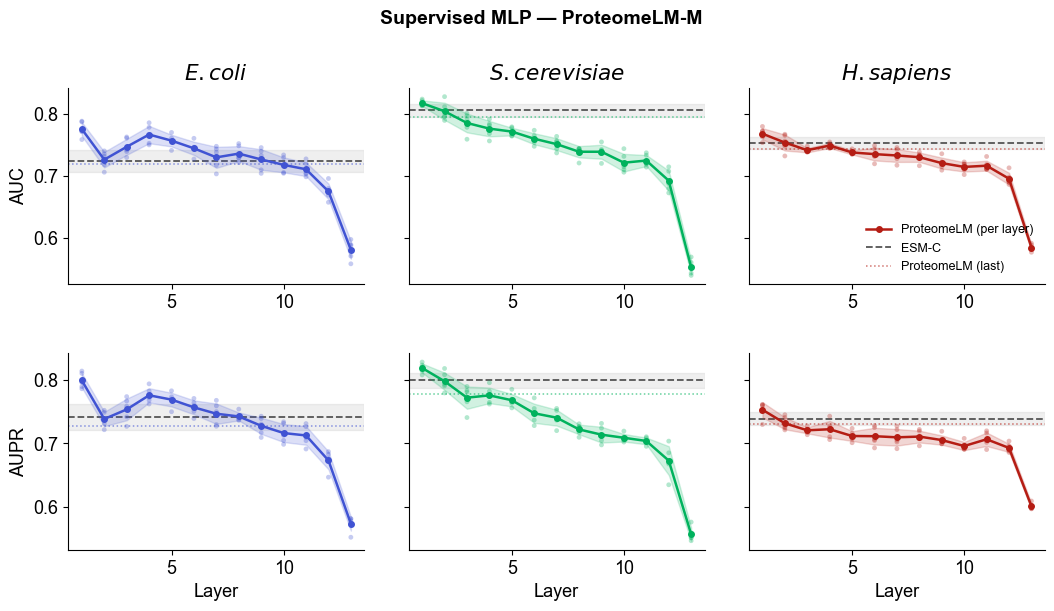

In [4]:
# ============================================================
# PLOT 1: AUC & AUPR vs Layer — compact 2×3 grid
#   Rows: AUC / AUPR  |  Columns: species
#   ProteomeLM per-layer as line+ribbon, ESM-C as horizontal band
# ============================================================
model = "ProteomeLM-M"  # or "ProteomeLM-S"
arch = model_architectures[model]

fig, axes = plt.subplots(2, len(species_names), figsize=(4.2 * len(species_names), 6),
                         sharex=False, sharey='row')
plt.subplots_adjust(hspace=0.35, wspace=0.15)

for col_idx, (spec, clean_spec) in enumerate(zip(species_names, clean_species_names)):
    if spec not in screening_dfs:
        continue
    df = screening_dfs[spec]
    color_spec = colors_pals[spec]
    cmap = to_colormap(color_spec)

    for row_idx, metric in enumerate(["AUC", "AUPR"]):
        ax = axes[row_idx, col_idx]

        # --- ProteomeLM per-layer ---
        layers, means, stds, all_vals = get_layer_curve(
            df, model, metric, arch["layer_range"])
        ax.plot(layers, means, color=color_spec, marker='o', markersize=4,
                linewidth=1.8, label='ProteomeLM (per layer)', zorder=3)
        ax.fill_between(layers, means - stds, means + stds,
                        color=color_spec, alpha=0.18, zorder=2)
        # individual replica dots
        for l_idx, (layer, vals) in enumerate(zip(layers, all_vals)):
            ax.scatter([layer] * len(vals), vals, color=color_spec,
                       alpha=0.3, s=12, zorder=2, edgecolors='none')

        # --- ESM-C baseline (horizontal band) ---
        esm_mean, esm_std, esm_vals = get_supervised_stats(
            df, model, metric, "ESM")
        ax.axhline(esm_mean, color='#555555', linestyle='--', linewidth=1.3,
                   label='ESM-C', zorder=1)
        ax.axhspan(esm_mean - esm_std, esm_mean + esm_std,
                   color='gray', alpha=0.12, zorder=0)

        # --- ProteomeLM last-layer (best) ---
        plm_mean, plm_std, _ = get_supervised_stats(
            df, model, metric, "ProteomeLM")
        ax.axhline(plm_mean, color=color_spec, linestyle=':', linewidth=1.1,
                   alpha=0.6, label='ProteomeLM (last)', zorder=1)

        # cosmetics
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if row_idx == 1:
            ax.set_xlabel('Layer')
        if col_idx == 0:
            ax.set_ylabel(metric)
        if row_idx == 0:
            ax.set_title(f"$\\mathbf{{\\it{{{clean_spec}}}}}$", fontweight='bold')
        if row_idx == 0 and col_idx == len(species_names) - 1:
            ax.legend(fontsize=9, frameon=False, loc='lower right')

plt.suptitle(f'Supervised MLP — {clean_model_sizes[models_to_plot.index(model)]}',
             fontweight='bold', y=1.01, fontsize=14)
plt.savefig("layer_curve_esm_vs_proteomelm.svg", dpi=300, bbox_inches='tight')
plt.show()

In [5]:
esm_mean

0.7388377199767365

## 2. Same plot for ProteomeLM-S

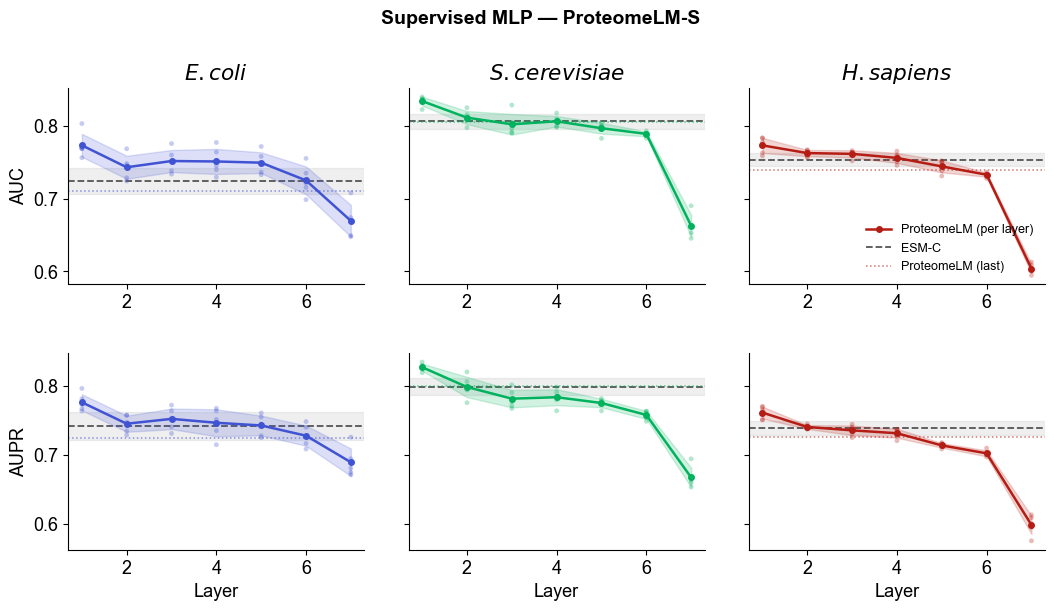

In [6]:
model = "ProteomeLM-S"
arch = model_architectures[model]

fig, axes = plt.subplots(2, len(species_names), figsize=(4.2 * len(species_names), 6),
                         sharex=False, sharey='row')
plt.subplots_adjust(hspace=0.35, wspace=0.15)

for col_idx, (spec, clean_spec) in enumerate(zip(species_names, clean_species_names)):
    if spec not in screening_dfs:
        continue
    df = screening_dfs[spec]
    color_spec = colors_pals[spec]
    cmap = to_colormap(color_spec)

    for row_idx, metric in enumerate(["AUC", "AUPR"]):
        ax = axes[row_idx, col_idx]
        layers, means, stds, all_vals = get_layer_curve(
            df, model, metric, arch["layer_range"])
        ax.plot(layers, means, color=color_spec, marker='o', markersize=4,
                linewidth=1.8, label='ProteomeLM (per layer)', zorder=3)
        ax.fill_between(layers, means - stds, means + stds,
                        color=color_spec, alpha=0.18, zorder=2)
        for l_idx, (layer, vals) in enumerate(zip(layers, all_vals)):
            ax.scatter([layer] * len(vals), vals, color=color_spec,
                       alpha=0.3, s=12, zorder=2, edgecolors='none')

        esm_mean, esm_std, _ = get_supervised_stats(df, model, metric, "ESM")
        ax.axhline(esm_mean, color='#555555', linestyle='--', linewidth=1.3,
                   label='ESM-C', zorder=1)
        ax.axhspan(esm_mean - esm_std, esm_mean + esm_std,
                   color='gray', alpha=0.12, zorder=0)

        plm_mean, _, _ = get_supervised_stats(df, model, metric, "ProteomeLM")
        ax.axhline(plm_mean, color=color_spec, linestyle=':', linewidth=1.1,
                   alpha=0.6, label='ProteomeLM (last)', zorder=1)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if row_idx == 1:
            ax.set_xlabel('Layer')
        if col_idx == 0:
            ax.set_ylabel(metric)
        if row_idx == 0:
            ax.set_title(f"$\\mathbf{{\\it{{{clean_spec}}}}}$", fontweight='bold')
        if row_idx == 0 and col_idx == len(species_names) - 1:
            ax.legend(fontsize=9, frameon=False, loc='lower right')

plt.suptitle(f'Supervised MLP — ProteomeLM-S', fontweight='bold', y=1.01, fontsize=14)
plt.savefig("layer_curve_esm_vs_proteomelm_S.svg", dpi=300, bbox_inches='tight')
plt.show()

## 3. Compact bar comparison: feature combinations (ProteomeLM vs ESM-C vs combined)

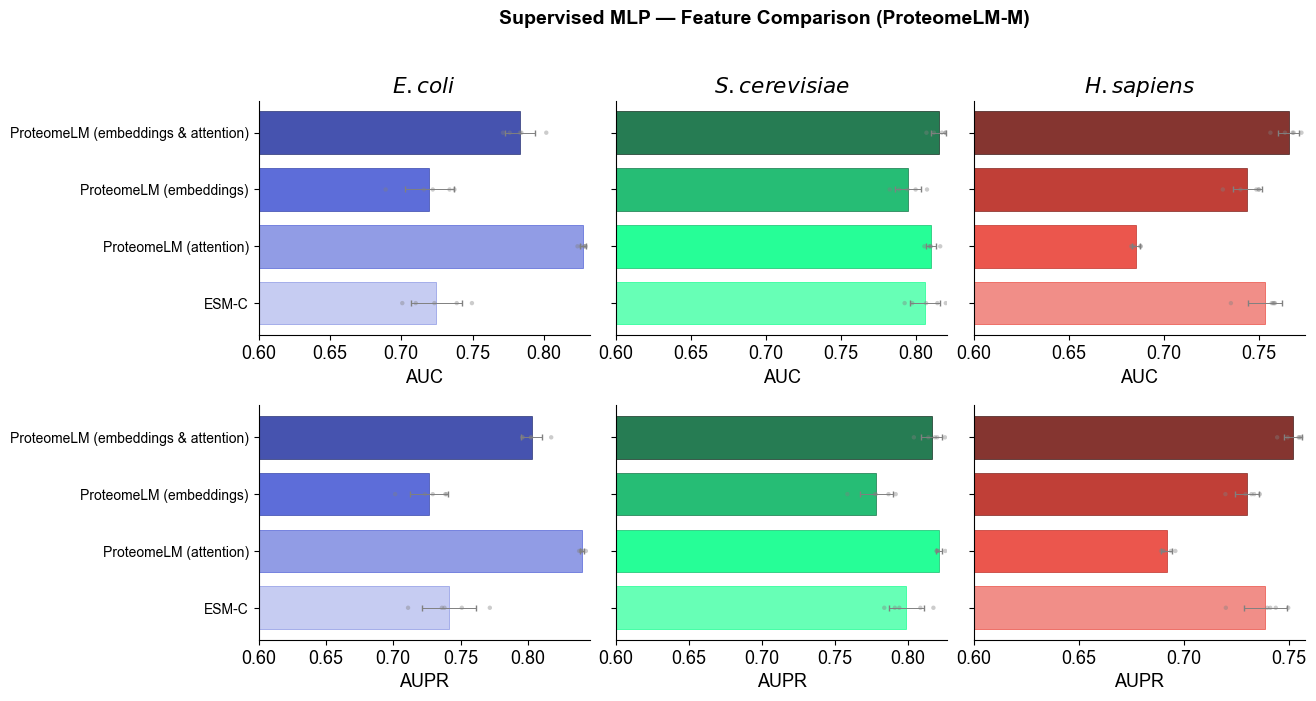

In [7]:
# ============================================================
# PLOT 2: Feature combination comparison — one panel per species
#   Rows: AUC / AUPR  |  Columns: species
#   Each panel shows horizontal bars for all feature combos
#   with replica dots, clean labels, species-colored bars
# ============================================================
model = "ProteomeLM-M"
feature_sets = ["ESM", "Att", "ProteomeLM", 
                "ProteomeLM+Att"]
clean_feature_names = ["ESM-C", "ProteomeLM (attention)", "ProteomeLM (embeddings)", 
                       "ProteomeLM (embeddings & attention)"]

# Group dividers: single features (0-2), pairs (3-4), combos (5-6)

n_sp = len([s for s in species_names if s in screening_dfs])
fig, axes = plt.subplots(2, n_sp, figsize=(4.5 * n_sp, 7),
                         sharey=True, sharex=False)
plt.subplots_adjust(hspace=0.3, wspace=0.08)
if n_sp == 1:
    axes = axes.reshape(2, 1)

for row_idx, metric in enumerate(["AUC", "AUPR"]):
    for col_idx, (spec, clean_spec) in enumerate(
        [(s, cs) for s, cs in zip(species_names, clean_species_names) if s in screening_dfs]):
        df = screening_dfs[spec]
        color_spec = colors_pals[spec]
        palette = to_palette(color_spec, len(feature_sets) + 1)

        ax = axes[row_idx, col_idx]

        # Compute y positions with group gaps
        y_positions = []
        cumul = 0
        for f_idx in range(len(feature_sets)):
            y_positions.append(cumul)
            cumul += 1
        y_positions = np.array(y_positions)

        means, stds, all_dots = [], [], []
        for feat in feature_sets:
            m, s, v = get_supervised_stats(df, model, metric, feat)
            means.append(m)
            stds.append(s)
            all_dots.append(v)

        # Draw bars
        for f_idx in range(len(feature_sets)):
            ax.barh(y_positions[f_idx], means[f_idx], height=0.75,
                    color=palette[f_idx], alpha=0.85,
                    edgecolor=palette[min(f_idx + 1, len(palette) - 1)],
                    linewidth=0.5,
                    xerr=stds[f_idx],
                    error_kw={'ecolor': 'gray', 'capsize': 2, 'elinewidth': 0.7})
            # Replica dots
            if all_dots[f_idx]:
                ax.scatter(all_dots[f_idx],
                           [y_positions[f_idx]] * len(all_dots[f_idx]),
                           color='gray', alpha=0.4, s=10, zorder=4,
                           edgecolors='none')

        # Smart x-limits based on min/max of mean±std and dots (robust to empty/NaN)
        vals = []
        mean_std = np.array(means) - np.array(stds)
        mean_std_hi = np.array(means) + np.array(stds)
        vals.extend(mean_std[~np.isnan(mean_std)].tolist())
        vals.extend(mean_std_hi[~np.isnan(mean_std_hi)].tolist())

        dots_flat = [v for sub in all_dots for v in sub if not np.isnan(v)]
        vals.extend(dots_flat)

        if vals:
            x_min, x_max = min(vals), max(vals)
            pad = 0.02 * (x_max - x_min) if x_max > x_min else 0.01
            ax.set_xlim(0.6, x_max + pad)
        else:
            ax.set_xlim(0, 1)

        # Y-axis labels (only leftmost column)
        ax.set_yticks(y_positions)
        ax.set_yticklabels(clean_feature_names, fontsize=10)

        # Group separator lines

        ax.set_xlabel(metric)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.invert_yaxis()

        if row_idx == 0:
            ax.set_title(f"$\\mathbf{{\\it{{{clean_spec}}}}}$", fontweight='bold')

plt.suptitle(f'Supervised MLP — Feature Comparison ({clean_model_sizes[models_to_plot.index(model)]})',
             fontweight='bold', y=1.01, fontsize=14)
plt.savefig("feature_comparison_barh.svg", dpi=300, bbox_inches='tight')
plt.show()

In [8]:
clean_feature_names

['ESM-C',
 'ProteomeLM (attention)',
 'ProteomeLM (embeddings)',
 'ProteomeLM (embeddings & attention)']

## 4. Compact: AUC & AUPR per layer, all species overlaid (single panel per metric)

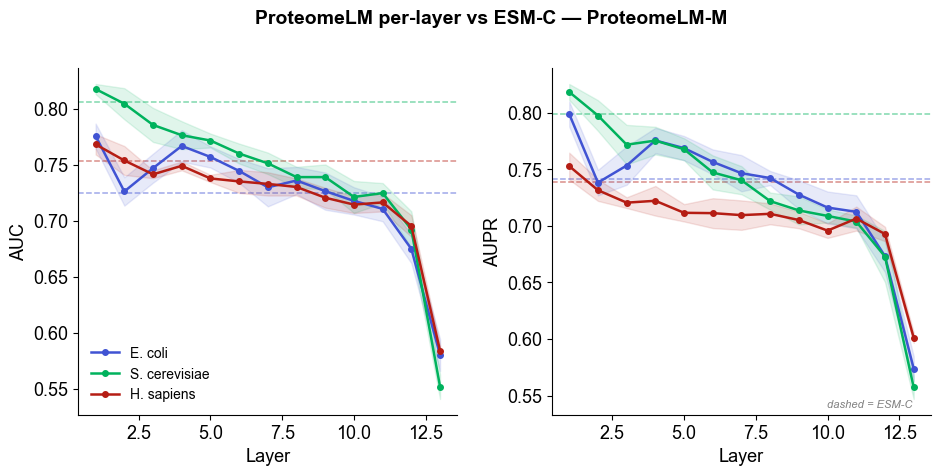

In [9]:
# ============================================================
# PLOT 3: All species overlaid on the same axes
#   Left: AUC vs layer  |  Right: AUPR vs layer
#   ESM-C baselines as dashed horizontal lines per species
# ============================================================
model = "ProteomeLM-M"
arch = model_architectures[model]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=False)
plt.subplots_adjust(wspace=0.25)

for k, metric in enumerate(["AUC", "AUPR"]):
    ax = axes[k]

    for spec, clean_spec in zip(species_names, clean_species_names):
        if spec not in screening_dfs:
            continue
        df = screening_dfs[spec]
        color_spec = colors_pals[spec]

        # Per-layer curve
        layers, means, stds, all_vals = get_layer_curve(
            df, model, metric, arch["layer_range"])
        ax.plot(layers, means, color=color_spec, marker='o', markersize=4,
                linewidth=1.8, label=f'{clean_spec}', zorder=3)
        ax.fill_between(layers, means - stds, means + stds,
                        color=color_spec, alpha=0.12, zorder=2)

        # ESM-C baseline
        esm_mean, esm_std, _ = get_supervised_stats(df, model, metric, "ESM")
        ax.axhline(esm_mean, color=color_spec, linestyle='--', linewidth=1.1,
                   alpha=0.5, zorder=1)

    ax.set_xlabel('Layer')
    ax.set_ylabel(metric)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if k == 0:
        ax.legend(fontsize=10, frameon=False)

    # Add annotation for ESM-C dashed lines
    if k == 1:
        ax.annotate('dashed = ESM-C', xy=(0.95, 0.02), xycoords='axes fraction',
                    fontsize=8, ha='right', color='gray', style='italic')

plt.suptitle(f'ProteomeLM per-layer vs ESM-C — {clean_model_sizes[models_to_plot.index(model)]}',
             fontweight='bold', y=1.01, fontsize=14)
plt.savefig("layer_curve_all_species_overlay.svg", dpi=300, bbox_inches='tight')
plt.show()

## 5. Compact summary: ESM-C vs ProteomeLM (best layer) vs ProteomeLM (last layer)

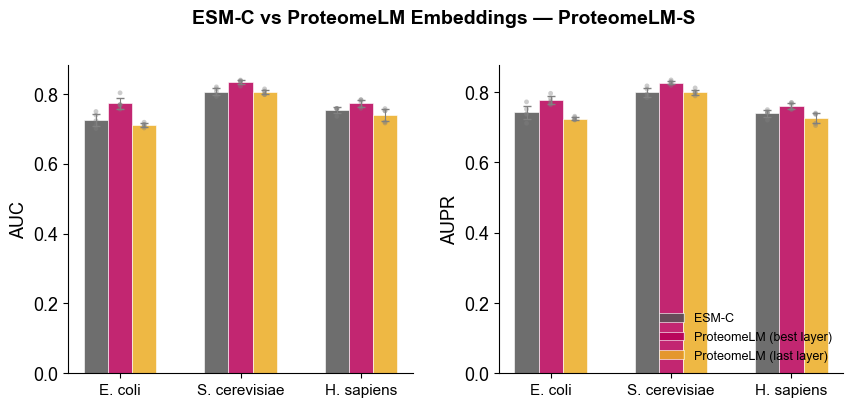

In [10]:
# ============================================================
# PLOT 4: Grouped bar chart — ESM-C vs ProteomeLM best-layer
#   vs ProteomeLM last layer, for each species × metric
# ============================================================
model = "ProteomeLM-S"
arch = model_architectures[model]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
plt.subplots_adjust(wspace=0.25)

bar_width = 0.2
method_colors = ['#555555', colorspal12[1], colorspal12[0]]
method_names = ['ESM-C', 'ProteomeLM (best layer)', 'ProteomeLM (last layer)']

for k, metric in enumerate(["AUC", "AUPR"]):
    ax = axes[k]
    x_base = np.arange(len([s for s in species_names if s in screening_dfs]))

    plot_species = [(spec, cs) for spec, cs in zip(species_names, clean_species_names)
                    if spec in screening_dfs]

    for m_idx, method in enumerate(['esm', 'best_layer', 'last_layer']):
        vals_mean, vals_std, vals_dots = [], [], []
        for spec, _ in plot_species:
            df = screening_dfs[spec]
            if method == 'esm':
                m, s, v = get_supervised_stats(df, model, metric, "ESM")
            elif method == 'best_layer':
                layers, means, stds, all_v = get_layer_curve(
                    df, model, metric, arch["layer_range"])
                best_idx = np.argmax(means)
                m, s, v = means[best_idx], stds[best_idx], all_v[best_idx]
            else:  # last_layer
                m, s, v = get_supervised_stats(df, model, metric, "ProteomeLM")
            vals_mean.append(m)
            vals_std.append(s)
            vals_dots.append(v)

        offset = (m_idx - 1) * bar_width
        ax.bar(x_base + offset, vals_mean, width=bar_width,
               color=method_colors[m_idx], alpha=0.85,
               edgecolor='white', linewidth=0.5,
               label=method_names[m_idx],
               yerr=vals_std,
               error_kw={'ecolor': 'gray', 'capsize': 3, 'elinewidth': 0.8})

        for s_idx, vals in enumerate(vals_dots):
            ax.scatter([x_base[s_idx] + offset] * len(vals), vals,
                       color='gray', alpha=0.4, s=12, zorder=4, edgecolors='none')

    ax.set_xticks(x_base)
    ax.set_xticklabels([cs for _, cs in plot_species], fontsize=11)
    ax.set_ylabel(metric)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if k == 1:
        ax.legend(fontsize=9, frameon=False, loc='lower right')

plt.suptitle(f'ESM-C vs ProteomeLM Embeddings — {clean_model_sizes[models_to_plot.index(model)]}',
             fontweight='bold', y=1.02, fontsize=14)
plt.savefig("esm_vs_proteomelm_summary_bars.svg", dpi=300, bbox_inches='tight')
plt.show()

## 7. Compact: ProteomeLM-S vs ProteomeLM-M per-layer comparison

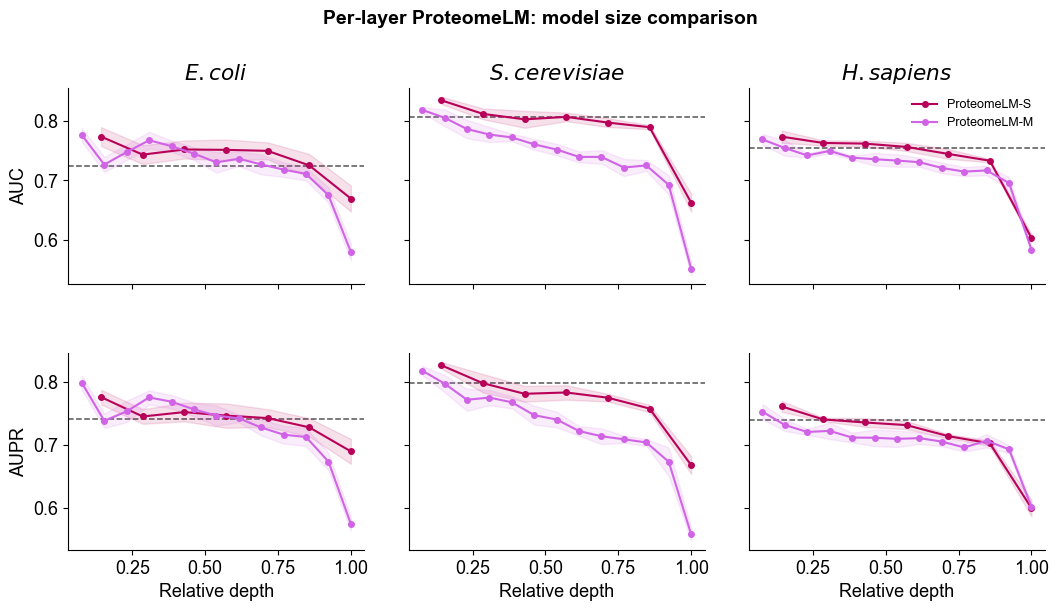

In [11]:
# ============================================================
# PLOT 6: Both model sizes overlaid per species
#   Normalised layer axis (fraction of total depth)
# ============================================================
fig, axes = plt.subplots(2, len(species_names), figsize=(4.2 * len(species_names), 6),
                         sharex=True, sharey='row')
plt.subplots_adjust(hspace=0.35, wspace=0.15)

size_colors = [colorspal12[1], colorspal12[5]]  # light/dark for S/M
size_labels = ['ProteomeLM-S', 'ProteomeLM-M']

for col_idx, (spec, clean_spec) in enumerate(zip(species_names, clean_species_names)):
    if spec not in screening_dfs:
        continue
    df = screening_dfs[spec]

    for row_idx, metric in enumerate(["AUC", "AUPR"]):
        ax = axes[row_idx, col_idx]

        for m_idx, model in enumerate(models_to_plot):
            arch = model_architectures[model]
            layers, means, stds, _ = get_layer_curve(
                df, model, metric, arch["layer_range"])
            # Normalise to [0, 1] depth
            frac = layers / layers.max()
            ax.plot(frac, means, color=size_colors[m_idx], marker='o',
                    markersize=4, linewidth=1.5, label=size_labels[m_idx], zorder=3)
            ax.fill_between(frac, means - stds, means + stds,
                            color=size_colors[m_idx], alpha=0.12, zorder=2)

        # ESM-C (same for both sizes since ESM embeddings don't change)
        esm_mean, _, _ = get_supervised_stats(df, models_to_plot[0], metric, "ESM")
        ax.axhline(esm_mean, color='#555555', linestyle='--', linewidth=1.1,
                   label='ESM-C' if m_idx == 0 else '', zorder=1)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if row_idx == 1:
            ax.set_xlabel('Relative depth')
        if col_idx == 0:
            ax.set_ylabel(metric)
        if row_idx == 0:
            ax.set_title(f"$\\mathbf{{\\it{{{clean_spec}}}}}$", fontweight='bold')
        if row_idx == 0 and col_idx == len(species_names) - 1:
            ax.legend(fontsize=9, frameon=False)

plt.suptitle('Per-layer ProteomeLM: model size comparison',
             fontweight='bold', y=1.01, fontsize=14)
plt.savefig("layer_curve_size_comparison.svg", dpi=300, bbox_inches='tight')
plt.show()